# LightGBM baseline: wetland to developed conversion, spatial CV

Trains one LightGBM model per spatial CV fold on `data/datasets/data_pool.parquet`
(from `assign_balanced_spatial_folds` in `helpers.py`, blocks balanced by row count and
label==1 count, not a random split, so training and held out rows never come from
neighboring pixels). Sample weight corrects label==1 rows back to label==1's true
statewide probability, accounting for the pool's own positive enrichment (block
selection chases label==1 density) on the way there, so the loss and every metric below
reflect Florida's real class balance instead of the pool's inflated one.

Reported for both the training folds and the held out fold, per fold: PR-AUC, ROC-AUC
(read "Accuracy AUC" as ROC-AUC, the area under the ROC curve, the standard AUC metric
distinct from PR-AUC; say if something else was meant), precision and recall at a set of
probability thresholds, and the per boosting round loss curve.

In [18]:
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, roc_curve
from matplotlib.lines import Line2D

from helpers import assign_balanced_spatial_folds, natural_pos_weight_mult, pos_class_sample_weight

## Setup

In [19]:
DATA_POOL_PATH = "data/datasets/data_pool.parquet"
N_FOLDS = 5
SEED = 0
THRESHOLDS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9]

N_ESTIMATORS = 500
EARLY_STOPPING_ROUNDS = 30

FOLD_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]

MODEL_DIR = Path("models")
RESULTS_DIR = Path("results")
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# left at None by default: the sample weight cell below computes the true-distribution
# correction on its own. run the toggle cell right before it to override to 1.0 instead,
# which trains on the pool's own balance (the "balanced objective") for comparison.
weight_pos_override = None

## Load the pool and assign spatial CV folds

Fold assignment happens at the block level (`assign_balanced_spatial_folds`), then gets
joined back onto every row in the pool by `block_id`, so every row from the same block
always lands in the same fold.

In [20]:
pool = pd.read_parquet(DATA_POOL_PATH)

folds = assign_balanced_spatial_folds(DATA_POOL_PATH, n_folds=N_FOLDS, seed=SEED)
pool = pool.merge(folds[["block_id", "fold"]], on="block_id", how="left")
assert pool["fold"].notna().all(), "every row should trace back to a block in the fold assignment"

FEATURE_COLS = [c for c in pool.columns if c not in ("label", "block_id", "fold")]

print(f"{len(pool):,} rows, {len(FEATURE_COLS)} features, {N_FOLDS} folds")
print(pool.groupby("fold")["label"].agg(n_rows="size", n_pos="sum"))

10,233,887 rows, 321 features, 5 folds
       n_rows  n_pos
fold                
0     1970995  31491
1     2050619  30310
2     2109900  29429
3     2106229  29517
4     1996144  31117


## Sample weights: correcting for the pool's own positive enrichment

`natural_pos_weight_mult` is n_neg/n_pos in the true statewide population, about 356 to
1. The pool is already enriched for positives on top of that (block selection chases
label==1 density), so weighting label==1 rows by 356 directly double corrects: it
overshoots past the true rate and lands the weighted positive share around 84 percent
instead of Florida's real about 0.28 percent. `pos_class_sample_weight` accounts for how
enriched this specific pool is before applying the statewide correction, so the weighted
rate lands where it should.

There's an optional toggle cell right before the weight computation: run it to override
`weight_pos` to 1.0 and train on the balanced objective instead (the pool's own 1.48
percent rate, uncorrected), as a comparison point against the true-distribution
objective below. Skip it, or rerun the Setup cell to reset the override to `None`, to go
back to the corrected weight.

In [21]:
# Optional. Run this cell, then the one below, to train on the balanced objective
# instead: label==1 rows keep the pool's own weight of 1, no correction toward the true
# statewide rate. Skip this cell (or rerun the Setup cell above to reset it to None) and
# the cell below computes and applies the true-distribution correction on its own.
weight_pos_override = 1.0

In [22]:
pos_weight_mult = natural_pos_weight_mult()
weight_pos = weight_pos_override if weight_pos_override is not None else pos_class_sample_weight(pool["label"], pos_weight_mult)

pool_pos_rate = (pool["label"] == 1).mean()
true_pos_rate = 1 / (1 + pos_weight_mult)
print(f"statewide n_neg/n_pos = {pos_weight_mult:.2f}, true positive rate = {true_pos_rate:.4%}")
print(f"pool's own positive rate = {pool_pos_rate:.4%}")
print(f"weight_pos = {weight_pos:.4f}" + (" (override)" if weight_pos_override is not None else ""))

pool["sample_weight"] = np.where(pool["label"] == 1, weight_pos, 1.0)

weighted_pos_share = pool.loc[pool["label"] == 1, "sample_weight"].sum() / pool["sample_weight"].sum()
print(f"weighted positive share in the pool = {weighted_pos_share:.4%} (true rate is {true_pos_rate:.4%}, pool's own rate is {pool_pos_rate:.4%})")

statewide n_neg/n_pos = 356.25, true positive rate = 0.2799%
pool's own positive rate = 1.4839%
weight_pos = 1.0000 (override)
weighted positive share in the pool = 1.4839% (true rate is 0.2799%, pool's own rate is 1.4839%)


## Metrics helpers

Precision and recall at a threshold, and PR-AUC/ROC-AUC, all computed with
`sample_weight` so they reflect the true statewide class balance the model was trained
against rather than the pool's own positive rate.

In [23]:
def threshold_metrics(y_true, y_score, weight, thresholds):
    """Weighted precision/recall at each threshold, one row per threshold."""
    rows = []
    for t in thresholds:
        pred = y_score >= t
        tp = weight[pred & (y_true == 1)].sum()
        fp = weight[pred & (y_true == 0)].sum()
        fn = weight[~pred & (y_true == 1)].sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        rows.append({"metric": "precision", "threshold": t, "value": precision})
        rows.append({"metric": "recall", "threshold": t, "value": recall})
    return rows


def summary_metrics(y_true, y_score, weight, thresholds):
    """PR-AUC, ROC-AUC ("accuracy AUC"), and weighted precision/recall at each
    threshold, as a list of tidy rows: metric, threshold (nan for the AUCs), value.
    """
    rows = [
        {"metric": "pr_auc", "threshold": np.nan,
         "value": average_precision_score(y_true, y_score, sample_weight=weight)},
        {"metric": "roc_auc", "threshold": np.nan,
         "value": roc_auc_score(y_true, y_score, sample_weight=weight)},
    ]
    rows += threshold_metrics(y_true, y_score, weight, thresholds)
    return rows

## Train one LightGBM model per fold

Each fold in turn plays the held out validation set; the model trains on the other
`N_FOLDS - 1` folds. `eval_set` carries both the training data and the held out fold so
LightGBM records a loss curve for each, but LightGBM's early stopping explicitly ignores
whichever eval set matches the training data, so it's really only the held out fold's
metrics driving the stop, checked across all three (`binary_logloss`, `auc`,
`average_precision`) since `first_metric_only` is left at its default False; training
continues as long as any one of them is still improving. This is a first pass baseline,
default LightGBM hyperparameters otherwise, worth tuning once these numbers are in
hand.

In [24]:
summary_rows = []
curve_rows = []
models = {}

for fold in range(N_FOLDS):
    train_mask = pool["fold"] != fold
    valid_mask = pool["fold"] == fold

    X_train = pool.loc[train_mask, FEATURE_COLS]
    y_train = pool.loc[train_mask, "label"].to_numpy()
    w_train = pool.loc[train_mask, "sample_weight"].to_numpy()

    X_valid = pool.loc[valid_mask, FEATURE_COLS]
    y_valid = pool.loc[valid_mask, "label"].to_numpy()
    w_valid = pool.loc[valid_mask, "sample_weight"].to_numpy()

    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=N_ESTIMATORS,
        random_state=SEED,
    )
    model.fit(
        X_train,
        y_train,
        sample_weight=w_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_names=["train", "valid"],
        eval_sample_weight=[w_train, w_valid],
        eval_metric=["binary_logloss", "auc", "average_precision"],
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS)],
    )
    models[fold] = model

    for split_name, X, y, w in [("train", X_train, y_train, w_train), ("valid", X_valid, y_valid, w_valid)]:
        proba = model.predict_proba(X)[:, 1]
        for row in summary_metrics(y, proba, w, THRESHOLDS):
            summary_rows.append({"fold": fold, "split": split_name, **row})

    for split_name, metric_history in model.evals_result_.items():
        for metric_name, values in metric_history.items():
            for iteration, value in enumerate(values):
                curve_rows.append(
                    {"fold": fold, "split": split_name, "metric": metric_name, "iteration": iteration, "value": value}
                )

    print(f"fold {fold}: best_iteration={model.best_iteration_}")

summary_df = pd.DataFrame(summary_rows)
curve_df = pd.DataFrame(curve_rows)

/Users/druckenmillerlab/miniforge3/envs/wetlands/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 120373, number of negative: 8142519
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.639736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33720
[LightGBM] [Info] Number of data points in the train set: 8262892, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014568 -> initscore=-4.214260
[LightGBM] [Info] Start training from score -4.214260
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[44]	train's binary_logloss: 0.053624	train's auc: 0.915742	train's average_precision: 0.238486	valid's binary_logloss: 0.0666483	valid's auc: 0.85865	valid's average_precision: 0.115987
fold 0: best_iteration=44


/Users/druckenmillerlab/miniforge3/envs/wetlands/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 121554, number of negative: 8061714
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.671377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33832
[LightGBM] [Info] Number of data points in the train set: 8183268, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014854 -> initscore=-4.194523
[LightGBM] [Info] Start training from score -4.194523
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[17]	train's binary_logloss: 0.0591368	train's auc: 0.892062	train's average_precision: 0.199196	valid's binary_logloss: 0.0624636	valid's auc: 0.873602	valid's average_precision: 0.116549
fold 1: best_iteration=17


/Users/druckenmillerlab/miniforge3/envs/wetlands/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 122435, number of negative: 8001552
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.772287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33576
[LightGBM] [Info] Number of data points in the train set: 8123987, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015071 -> initscore=-4.179811
[LightGBM] [Info] Start training from score -4.179811
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[20]	train's binary_logloss: 0.0590681	train's auc: 0.897263	train's average_precision: 0.198968	valid's binary_logloss: 0.0595592	valid's auc: 0.865776	valid's average_precision: 0.112673
fold 2: best_iteration=20


/Users/druckenmillerlab/miniforge3/envs/wetlands/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 122347, number of negative: 8005311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.669716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33681
[LightGBM] [Info] Number of data points in the train set: 8127658, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015053 -> initscore=-4.180999
[LightGBM] [Info] Start training from score -4.180999
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[42]	train's binary_logloss: 0.0556606	train's auc: 0.910336	train's average_precision: 0.238322	valid's binary_logloss: 0.0568376	valid's auc: 0.891	valid's average_precision: 0.135714
fold 3: best_iteration=42


/Users/druckenmillerlab/miniforge3/envs/wetlands/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 120747, number of negative: 8116996
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.020828 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33372
[LightGBM] [Info] Number of data points in the train set: 8237743, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014658 -> initscore=-4.208018
[LightGBM] [Info] Start training from score -4.208018
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[56]	train's binary_logloss: 0.0535862	train's auc: 0.916327	train's average_precision: 0.250162	valid's binary_logloss: 0.0622444	valid's auc: 0.893193	valid's average_precision: 0.130689
fold 4: best_iteration=56


## Performance graphs: training loss, ROC curve, PR curves, precision/recall by threshold

Five separate figures. Training loss is still plotted per boosting round, train and
held out fold overlaid, so overfitting shows up directly as the two lines splitting
apart. ROC is the actual curve (not a value trending over rounds), held out predictions
only, computed from each fold's early stopped best iteration. PR is the same actual
curve, but split into two figures, one for training predictions and one for held out,
each with its own per fold average precision in the legend, so a fold's number is read
straight off the line instead of a separate lookup. The last panel takes the weighted
precision and recall table already computed in `summary_metrics` (also saved to
`gbm_summary_metrics.csv`) and plots both against the probability threshold that
produced them, held out folds only, so picking an operating threshold is a read off a
chart instead of a lookup into a table. Threshold axis is log scaled since the
interesting range for a rare event sits below 0.05, where a linear axis would flatten it
to nothing. Color carries fold identity throughout.

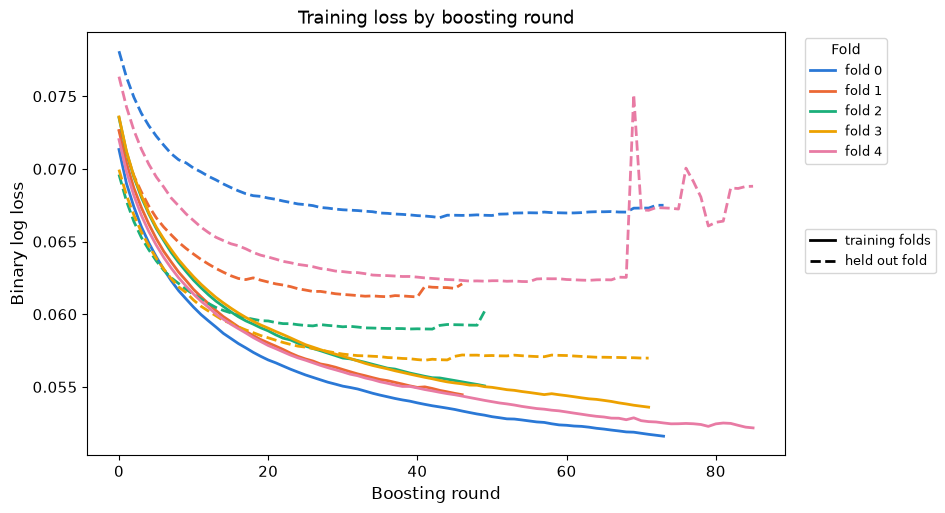

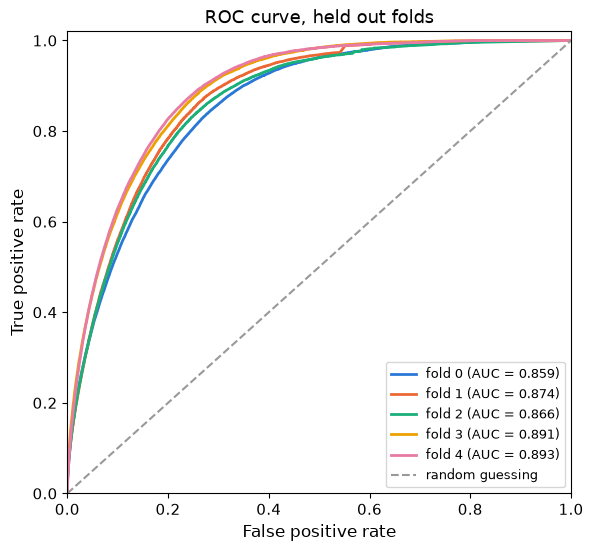

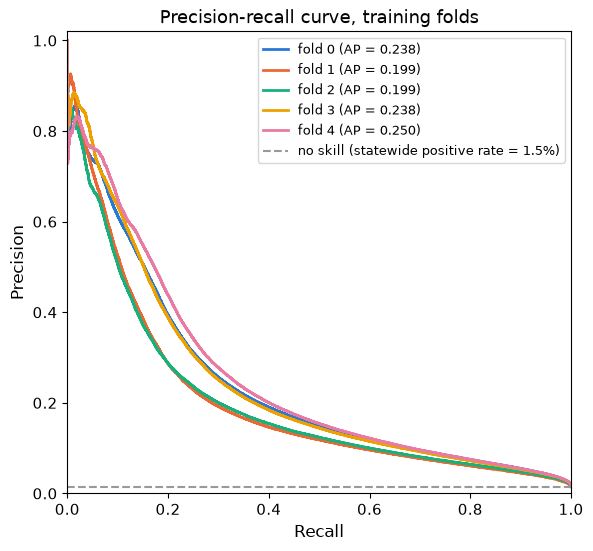

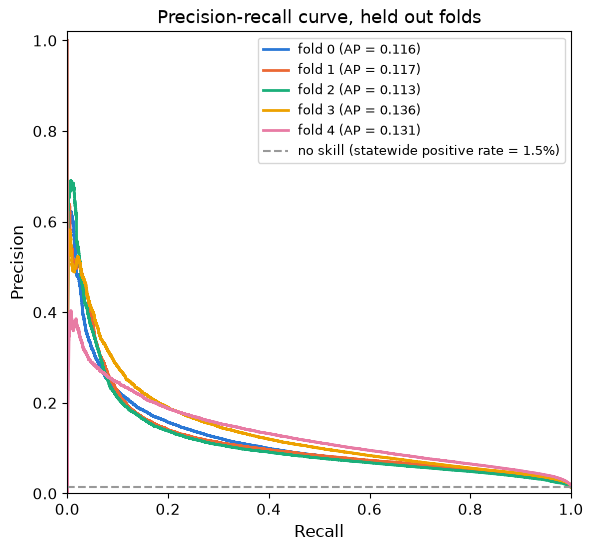

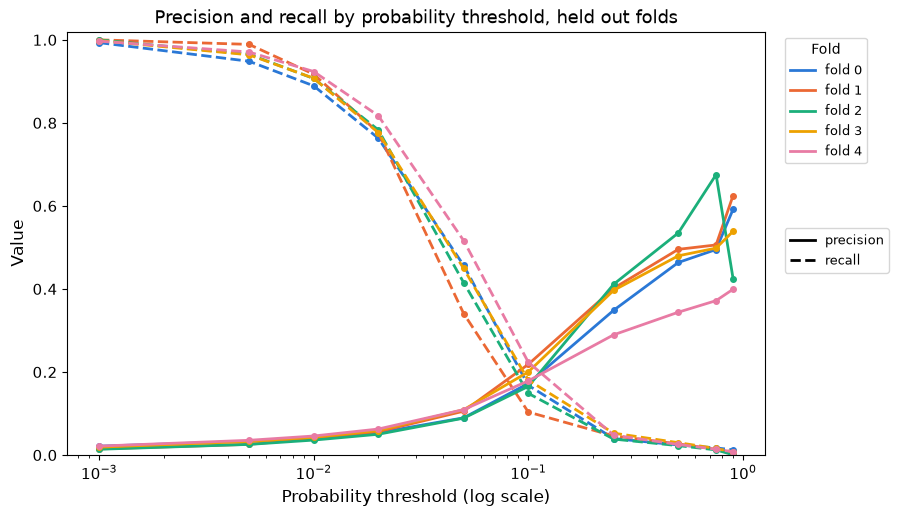

In [25]:


SPLIT_STYLE = {"train": "-", "valid": "--"}
SPLIT_LABEL = {"train": "training folds", "valid": "held out fold"}
METRIC_STYLE = {"precision": "-", "recall": "--"}


def plot_loss_curve():
    """Binary log loss per boosting round, train vs held out, all folds on one panel."""
    fig, ax = plt.subplots(figsize=(9, 5.5))

    for fold in range(N_FOLDS):
        fold_loss = curve_df[(curve_df["fold"] == fold) & (curve_df["metric"] == "binary_logloss")]
        for split in ("train", "valid"):
            split_curve = fold_loss[fold_loss["split"] == split]
            ax.plot(
                split_curve["iteration"],
                split_curve["value"],
                color=FOLD_COLORS[fold],
                linewidth=2,
                linestyle=SPLIT_STYLE[split],
            )

    ax.set_title("Training loss by boosting round", fontsize=13)
    ax.set_xlabel("Boosting round", fontsize=12)
    ax.set_ylabel("Binary log loss", fontsize=12)
    ax.tick_params(labelsize=11)

    fold_legend = ax.legend(
        handles=[Line2D([0], [0], color=FOLD_COLORS[f], linewidth=2) for f in range(N_FOLDS)],
        labels=[f"fold {f}" for f in range(N_FOLDS)],
        title="Fold",
        fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )
    ax.add_artist(fold_legend)
    ax.legend(
        handles=[Line2D([0], [0], color="black", linewidth=2, linestyle=SPLIT_STYLE[s]) for s in ("train", "valid")],
        labels=[SPLIT_LABEL[s] for s in ("train", "valid")],
        fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.55),
    )

    fig.savefig(RESULTS_DIR / "gbm_logloss_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


def fold_predictions(fold, split):
    """Recompute a fold's predictions for either split from its saved booster (cheap,
    just inference), so the curve plots below don't need the training loop rerun."""
    mask = pool["fold"] != fold if split == "train" else pool["fold"] == fold
    X = pool.loc[mask, FEATURE_COLS]
    y = pool.loc[mask, "label"].to_numpy()
    w = pool.loc[mask, "sample_weight"].to_numpy()
    proba = models[fold].predict_proba(X)[:, 1]
    return y, proba, w


def plot_roc_curve():
    """Actual ROC curve (FPR vs TPR) per fold, at each fold's early stopped best
    iteration, computed on held out predictions with the statewide sample weight."""
    fig, ax = plt.subplots(figsize=(6.5, 6))

    for fold in range(N_FOLDS):
        y_valid, proba, w_valid = fold_predictions(fold, "valid")
        fpr, tpr, _ = roc_curve(y_valid, proba, sample_weight=w_valid)
        auc = roc_auc_score(y_valid, proba, sample_weight=w_valid)
        ax.plot(fpr, tpr, color=FOLD_COLORS[fold], linewidth=2, label=f"fold {fold} (AUC = {auc:.3f})")

    ax.plot([0, 1], [0, 1], color="0.6", linewidth=1.5, linestyle="--", label="random guessing")
    ax.set_title("ROC curve, held out folds", fontsize=13)
    ax.set_xlabel("False positive rate", fontsize=12)
    ax.set_ylabel("True positive rate", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=9, loc="lower right")

    fig.savefig(RESULTS_DIR / "gbm_roc_curve.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_pr_curve(split, title, filename):
    """Precision recall curve per fold for one split, at each fold's early stopped
    best iteration, with each fold's average precision spelled out in the legend.
    """
    fig, ax = plt.subplots(figsize=(6.5, 6))

    natural_pos_rate = (pool["sample_weight"] * (pool["label"] == 1)).sum() / pool["sample_weight"].sum()

    for fold in range(N_FOLDS):
        y, proba, w = fold_predictions(fold, split)
        precision, recall, _ = precision_recall_curve(y, proba, sample_weight=w)
        ap = average_precision_score(y, proba, sample_weight=w)
        ax.plot(recall, precision, color=FOLD_COLORS[fold], linewidth=2, label=f"fold {fold} (AP = {ap:.3f})")

    ax.axhline(
        natural_pos_rate, color="0.6", linewidth=1.5, linestyle="--",
        label=f"no skill (statewide positive rate = {natural_pos_rate:.1%})",
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=9, loc="upper right")

    fig.savefig(RESULTS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_threshold_curve():
    """Weighted precision and recall against the probability threshold that produced
    them, held out folds only, straight from the summary_metrics table computed during
    training. Log x-axis since the operating thresholds worth looking at for a rare
    event are almost all below 0.05.
    """
    fig, ax = plt.subplots(figsize=(9, 5.5))

    for fold in range(N_FOLDS):
        fold_valid = summary_df[(summary_df["fold"] == fold) & (summary_df["split"] == "valid")]
        for metric in ("precision", "recall"):
            metric_curve = fold_valid[fold_valid["metric"] == metric].sort_values("threshold")
            ax.plot(
                metric_curve["threshold"],
                metric_curve["value"],
                color=FOLD_COLORS[fold],
                linewidth=2,
                linestyle=METRIC_STYLE[metric],
                marker="o",
                markersize=4,
            )

    ax.set_xscale("log")
    ax.set_title("Precision and recall by probability threshold, held out folds", fontsize=13)
    ax.set_xlabel("Probability threshold (log scale)", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.set_ylim(0, 1.02)
    ax.tick_params(labelsize=11)

    fold_legend = ax.legend(
        handles=[Line2D([0], [0], color=FOLD_COLORS[f], linewidth=2) for f in range(N_FOLDS)],
        labels=[f"fold {f}" for f in range(N_FOLDS)],
        title="Fold",
        fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )
    ax.add_artist(fold_legend)
    ax.legend(
        handles=[Line2D([0], [0], color="black", linewidth=2, linestyle=METRIC_STYLE[m]) for m in ("precision", "recall")],
        labels=["precision", "recall"],
        fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.55),
    )

    fig.savefig(RESULTS_DIR / "gbm_precision_recall_by_threshold.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_loss_curve()
plot_roc_curve()
plot_pr_curve("train", "Precision-recall curve, training folds", "gbm_pr_curve_train.png")
plot_pr_curve("valid", "Precision-recall curve, held out folds", "gbm_pr_curve_valid.png")
plot_threshold_curve()

## Feature importance

Gain importance, the total loss reduction credited to a feature's splits, averaged
across the 5 fold models. Gain is more informative than split count here, since a
feature can get split on often while barely reducing loss each time. The bars below
show the top 25 features by mean gain, with error bars for the standard deviation of
gain across folds, so a tall bar with an error bar nearly as tall isn't a feature to
trust for a story about what matters, it's just unstable across folds. The full 321
feature table, not just the top 25, is written to `results/gbm_feature_importance.csv`.

wrote results/gbm_feature_importance.csv (1,605 rows)


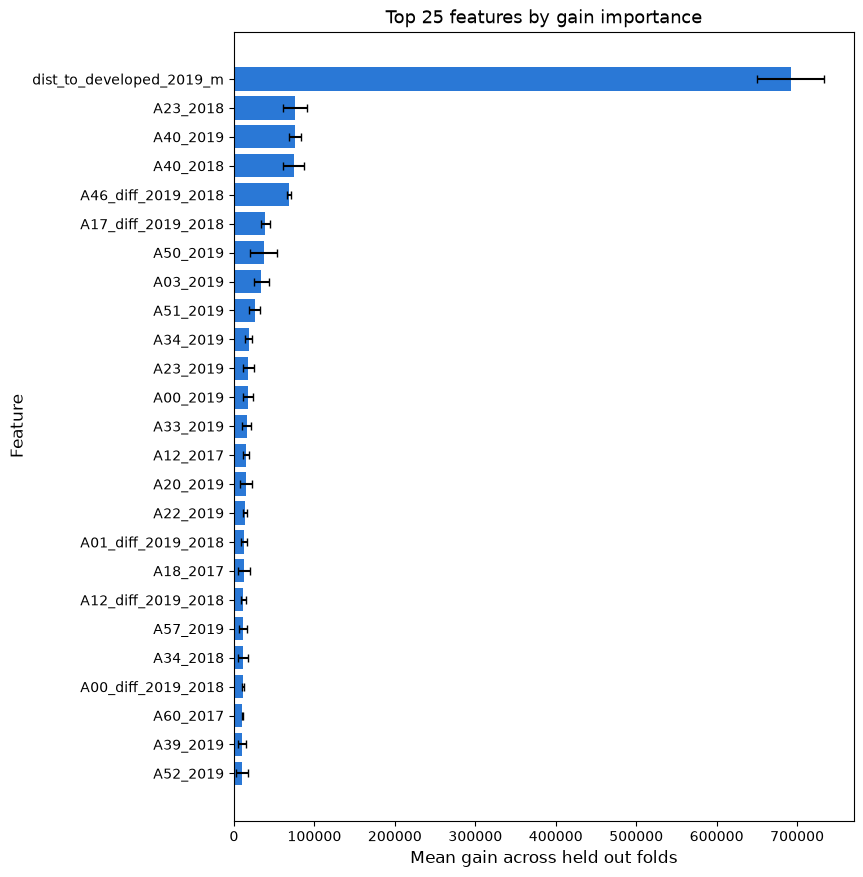

                          mean_gain  std_gain
feature                                      
dist_to_developed_2019_m  692,012.9  41,904.6
A23_2018                   76,042.1  14,487.8
A40_2019                   75,432.1   7,454.3
A40_2018                   74,420.9  12,884.4
A46_diff_2019_2018         68,372.8   2,918.7
A17_diff_2019_2018         38,880.9   5,763.1
A50_2019                   36,742.6  16,248.0
A03_2019                   34,076.0   8,878.4
A51_2019                   25,803.1   6,685.8
A34_2019                   18,148.1   3,952.8
A23_2019                   18,009.5   7,054.7
A00_2019                   17,203.4   6,040.2
A33_2019                   15,711.3   5,619.1
A12_2017                   15,172.7   3,963.5
A20_2019                   14,916.5   7,029.6
A22_2019                   13,536.8   2,191.9
A01_diff_2019_2018         12,882.4   3,947.5
A18_2017                   12,513.4   7,720.7
A12_diff_2019_2018         11,800.7   3,501.8
A57_2019                   11,225.

In [26]:
importance_rows = []
for fold, model in models.items():
    booster = model.booster_
    gain = booster.feature_importance(importance_type="gain")
    split = booster.feature_importance(importance_type="split")
    for feature, g, s in zip(FEATURE_COLS, gain, split):
        importance_rows.append({"fold": fold, "feature": feature, "gain": g, "split": s})

importance_df = pd.DataFrame(importance_rows)
importance_df.to_csv(RESULTS_DIR / "gbm_feature_importance.csv", index=False)
print(f"wrote {RESULTS_DIR / 'gbm_feature_importance.csv'} ({len(importance_df):,} rows)")

gain_summary = (
    importance_df.groupby("feature")["gain"]
    .agg(mean_gain="mean", std_gain="std")
    .sort_values("mean_gain", ascending=False)
)

TOP_N = 25
top_features = gain_summary.head(TOP_N)

fig, ax = plt.subplots(figsize=(8, 0.35 * TOP_N + 1.5))
y_pos = np.arange(len(top_features))
ax.barh(y_pos, top_features["mean_gain"], xerr=top_features["std_gain"], color="#2a78d6", capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features.index, fontsize=10)
ax.invert_yaxis()
ax.set_title(f"Top {TOP_N} features by gain importance", fontsize=13)
ax.set_xlabel("Mean gain across held out folds", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.tick_params(labelsize=10)

fig.savefig(RESULTS_DIR / "gbm_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(gain_summary.head(TOP_N).to_string(float_format=lambda x: f"{x:,.1f}"))

## Save metrics

Two tidy CSVs: `gbm_summary_metrics.csv` (PR-AUC, ROC-AUC, precision/recall per
threshold, one row each) and `gbm_training_curves.csv` (the per boosting round history
behind the loss/ROC-AUC/PR-AUC curve plots above). Both keyed by fold and split so either
can be filtered or regrouped without rerunning training.

In [27]:
summary_df.to_csv(RESULTS_DIR / "gbm_summary_metrics.csv", index=False)
curve_df.to_csv(RESULTS_DIR / "gbm_training_curves.csv", index=False)

print(f"wrote {RESULTS_DIR / 'gbm_summary_metrics.csv'} ({len(summary_df):,} rows)")
print(f"wrote {RESULTS_DIR / 'gbm_training_curves.csv'} ({len(curve_df):,} rows)")

wrote results/gbm_summary_metrics.csv (220 rows)
wrote results/gbm_training_curves.csv (1,974 rows)


## Save models

One booster per fold, LightGBM's native text format rather than a pickle, so a version
mismatch on some future read doesn't silently break unpickling.

In [12]:
for fold, model in models.items():
    model_path = MODEL_DIR / f"gbm_fold{fold}.txt"
    model.booster_.save_model(str(model_path))
    print(f"wrote {model_path}")

[LightGBM] [Fatal] Model file models/gbm_fold0.txt is not available for writes


LightGBMError: Model file models/gbm_fold0.txt is not available for writes